In [2]:
import qutip
import matplotlib
from qutip.piqs.piqs  import *
import numpy as np
import os
import time
import gc
os.environ["MOSEKLM_LICENSE_FILE"] = "/Users/46668993/Desktop/qer/mosek/mosek.lic"  # adjust path
from codes.noisemodel import*
from codes.codewords import*
from codes.optimisation import*
import matplotlib.pyplot as plt

In [ ]:

#codes = [(3, 3, 2), (5, 5, 2)]
codes = [(3, 3, 2)]
gamma = np.logspace(-5, -2, 10)
dt = 1
p_vals = np.array(gamma) * dt

plt.figure(figsize=(10, 6), dpi = 120)

#bare qubit for comparison
rho_bare = 0.5 * qeye(2)
infids_bare_global = []

#method: kraus or choi
method = 'choi'
method_norecovery = 'kraus'



rho, l0, l1 = bgmcode_piqs(b, g_code, m, return_qutip=True)
infids_global = []
infids_local = []
infids_norecovery_global = []
infids_norecovery_local = []

for g in gamma:
    print(f"Processing gamma={g:.2e}")

    try:
        # Global depolarizing
        t0 = time.perf_counter()
        kraus_global = noisemodel('global symmetric depolarizing', N, g, dt, method)
        t1 = time.perf_counter()
        print(f"  Global kraus in {t1 - t0:.2f}s")

        fid_global = optimise(l0, l1, kraus_global, solver='mosek')
        t2 = time.perf_counter()
        print(f"  Global optimise in {t2 - t1:.2f}s")
        
        infids_global.append(abs(1.0 - float(fid_global)))

        #bgm code without recovery operation
        infids_norecovery_global.append(abs(1.0 - float(no_recovery(rho, noisemodel('global symmetric depolarizing',N, g, dt, method_norecovery)))))

        #bare qubit infidelity for comparison
        fid_bare_global = optimise(qutip.basis(2,0), qutip.basis(2,1), noisemodel('global symmetric depolarizing',1,g,dt,method))
        infids_bare_global.append(abs(1.0 - float(fid_bare_global)))
        
        # Delete large objects immediately after use
        del kraus_global
        gc.collect()  # Force garbage collection
        
    except Exception as e:
        print(f"  ERROR (global): {e}")
        infids_global.append(np.nan)

    try:
        # Local depolarizing
        t3 = time.perf_counter()
        kraus_local = noisemodel('local symmetric depolarizing', N, g, dt, method)
        t4 = time.perf_counter()
        print(f"  Local kraus in {t4 - t3:.2f}s")

        fid_local = optimise(l0, l1, kraus_local, solver='mosek')
        t5 = time.perf_counter()
        print(f"  Local optimise in {t5 - t4:.2f}s")
        
        infids_local.append(abs(1.0 - float(fid_local)))

        #bgm code without recovery operation
        infids_norecovery_local.append(abs(1.0 - float(no_recovery(rho, noisemodel('local symmetric depolarizing',N, g, dt, method_norecovery)))))
        
        # Delete large objects immediately after use
        del kraus_local
        gc.collect()  # Force garbage collection
        
    except Exception as e:
        print(f"  ERROR (local): {e}")
        infids_local.append(np.nan)

# Process results
infids_global = np.array(infids_global, dtype=float) #bgm code after recovery
infids_bare_global = np.array(infids_bare_global, dtype=float) #bare qubit
infids_local = np.array(infids_local, dtype=float) #bgm code after recovery
infids_norecovery_global = np.array(infids_norecovery_global, dtype=float)#bgm code without recovery
infids_norecovery_local = np.array(infids_norecovery_local, dtype=float)#bgm code without recovery

mask_global = (infids_global > 0) & np.isfinite(infids_global)
mask_local = (infids_local > 0) & np.isfinite(infids_local)
mask_bare_global = (infids_bare_global > 0) & np.isfinite(infids_bare_global)
mask_infids_norecovery_global = (infids_norecovery_global > 0) & np.isfinite(infids_norecovery_global)
mask_infids_norecovery_local = (infids_norecovery_local > 0) & np.isfinite(infids_norecovery_local)

if np.any(mask_global):
    #plt.loglog(p_vals[mask_global], infids_global[mask_global], "o-", lw=1, label=f"bgm ({b},{g_code},{m}) optimum recovery (global)")
    plt.loglog(p_vals[mask_global], infids_global[mask_global], "o-", lw=1, label=f" optimum recovery (global)")
if np.any(mask_local):
    #plt.loglog(p_vals[mask_local], infids_local[mask_local], "s--", lw=1, label=f"bgm ({b},{g_code},{m}) optimum recovery (local)")
    plt.loglog(p_vals[mask_local], infids_local[mask_local], "s--", lw=1, label=f"optimum recovery (local)")
if np.any(mask_bare_global):
    plt.loglog(p_vals[mask_bare_global], infids_bare_global[mask_bare_global], "o-", lw=1, label="bare qubit")
if np.any(mask_infids_norecovery_global):
    #plt.loglog(p_vals[mask_infids_norecovery_global], infids_norecovery_global[mask_infids_norecovery_global], "x-", lw=1, label=f"bgm ({b},{g_code},{m}) no recovery (global)")
    plt.loglog(p_vals[mask_infids_norecovery_global], infids_norecovery_global[mask_infids_norecovery_global], "x-", lw=1, label=f"no recovery (global)")
if np.any(mask_infids_norecovery_local):
    #plt.loglog(p_vals[mask_infids_norecovery_local], infids_norecovery_local[mask_infids_norecovery_local], "x--", lw=1, label=f"bgm ({b},{g_code},{m}) no recovery (local)")
    plt.loglog(p_vals[mask_infids_norecovery_local], infids_norecovery_local[mask_infids_norecovery_local], "x--", lw=1, label=f"no recovery (local)")

# Clean up large objects for this code
del rho, l0, l1, infids_global, infids_local, infids_bare_global, infids_norecovery_global, infids_norecovery_local
gc.collect()

plt.xlabel("p = " + r"$\gamma \Delta t$")
plt.ylabel("|1 - F|")
plt.title("Performance of (3,3,2) bgm code")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

## Comparison Script: BGM vs GNU Codes

This script compares the performance of two permutation-invariant quantum error correcting codes:
- **BGM code**: (b, g, m) parametrization
- **GNU code**: (g, n, u) parametrization

**Features:**
- User-specified noise model (global or local symmetric depolarizing)
- Compares both codes with and without recovery operations
- Includes bare qubit baseline for reference
- Plots infidelity vs error probability on log-log scale

**To use:**
1. Set `noise_type` to your desired noise model
2. Adjust code parameters (b, g, m) for BGM and (g, n, u) for GNU
3. Run the cell to generate comparison plot

BGM code (3,3,1): N = 9 qubits
GNU code (3,3,1): N = 9 qubits
Noise model: global symmetric depolarizing

=== Initializing BGM code ===
=== Initializing GNU code ===

Processing gamma=1.00e-05
  BGM optimise in 2.37s
  GNU optimise in 2.25s

Processing gamma=2.15e-05
  BGM optimise in 2.21s
  GNU optimise in 2.10s

Processing gamma=4.64e-05
  BGM optimise in 3.47s
  GNU optimise in 4.56s

Processing gamma=1.00e-04
  BGM optimise in 3.59s
  GNU optimise in 3.90s

Processing gamma=2.15e-04
  BGM optimise in 2.53s
  GNU optimise in 2.54s

Processing gamma=4.64e-04
  BGM optimise in 2.35s
  GNU optimise in 2.31s

Processing gamma=1.00e-03
  BGM optimise in 2.30s
  GNU optimise in 2.32s

Processing gamma=2.15e-03
  BGM optimise in 2.49s
  GNU optimise in 2.37s

Processing gamma=4.64e-03
  BGM optimise in 2.51s
  GNU optimise in 2.42s

Processing gamma=1.00e-02
  BGM optimise in 2.50s
  GNU optimise in 2.27s


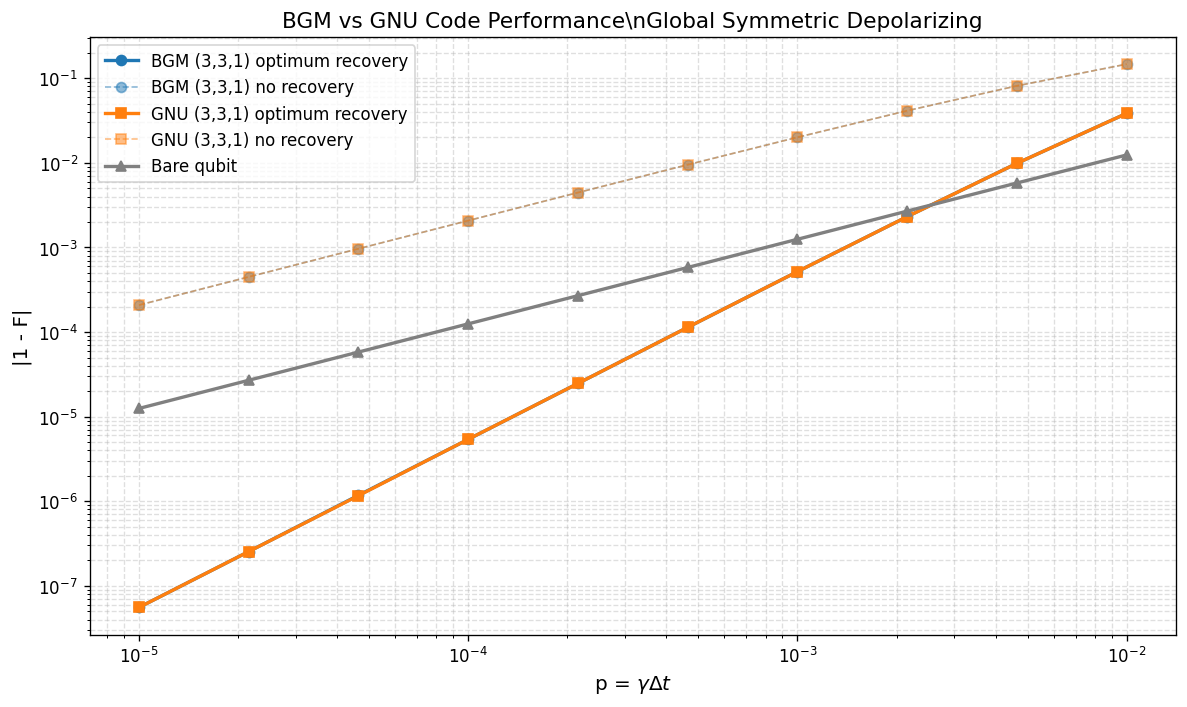


=== Simulation Complete ===


In [18]:
# ============================================================
# Comparison: BGM code vs GNU code
# ============================================================

# User-specified noise model
noise_type = 'global symmetric depolarizing'  # Options: 'global symmetric depolarizing', 'local symmetric depolarizing'

# Code parameters
# BGM code: (b, g, m) where N_bgm = 2*b*m + g
b, g_bgm, m = 3, 3, 1
N_bgm = 2*b*m + g_bgm

# GNU code: (g, n, u) where N_gnu = g*n*u
g_gnu, n, u = 3, 3, 1
N_gnu = g_gnu * n * u

print(f"BGM code ({b},{g_bgm},{m}): N = {N_bgm} qubits")
print(f"GNU code ({g_gnu},{n},{u}): N = {N_gnu} qubits")
print(f"Noise model: {noise_type}")

# Simulation parameters
gamma = np.logspace(-5, -2, 10)
dt = 1
p_vals = np.array(gamma) * dt

plt.figure(figsize=(10, 6), dpi=120)

# Method: kraus or choi
method = 'choi'
method_norecovery = 'kraus'

# Bare qubit for comparison
infids_bare = []

# BGM code results
print("\n=== Initializing BGM code ===")
rho_bgm, l0_bgm, l1_bgm = bgmcode_piqs(b, g_bgm, m, return_qutip=True)
infids_bgm_global = []
infids_bgm_local = []
infids_bgm_norecovery_global = []
infids_bgm_norecovery_local = []

# GNU code results
print("=== Initializing GNU code ===")
rho_gnu, l0_gnu, l1_gnu = gnucode_piqs(g_gnu, n, u, return_qutip=True)
infids_gnu_global = []
infids_gnu_local = []
infids_gnu_norecovery_global = []
infids_gnu_norecovery_local = []

# Main simulation loop
for g in gamma:
    print(f"\nProcessing gamma={g:.2e}")
    
    # ========== BGM Code ==========
    try:
        t0 = time.perf_counter()
        if 'global' in noise_type:
            kraus = noisemodel(noise_type, N_bgm, g, dt, method)
            fid = optimise(l0_bgm, l1_bgm, kraus, solver='mosek')
            infids_bgm_global.append(abs(1.0 - float(fid)))
            
            # No recovery
            infids_bgm_norecovery_global.append(abs(1.0 - float(
                no_recovery(rho_bgm, noisemodel(noise_type, N_bgm, g, dt, method_norecovery))
            )))
        else:
            kraus = noisemodel(noise_type, N_bgm, g, dt, method)
            fid = optimise(l0_bgm, l1_bgm, kraus, solver='mosek')
            infids_bgm_local.append(abs(1.0 - float(fid)))
            
            # No recovery
            infids_bgm_norecovery_local.append(abs(1.0 - float(
                no_recovery(rho_bgm, noisemodel(noise_type, N_bgm, g, dt, method_norecovery))
            )))
        
        t1 = time.perf_counter()
        print(f"  BGM optimise in {t1 - t0:.2f}s")
        del kraus
        gc.collect()
    except Exception as e:
        print(f"  ERROR (BGM): {e}")
        if 'global' in noise_type:
            infids_bgm_global.append(np.nan)
            infids_bgm_norecovery_global.append(np.nan)
        else:
            infids_bgm_local.append(np.nan)
            infids_bgm_norecovery_local.append(np.nan)
    
    # ========== GNU Code ==========
    try:
        t0 = time.perf_counter()
        if 'global' in noise_type:
            kraus = noisemodel(noise_type, N_gnu, g, dt, method)
            fid = optimise(l0_gnu, l1_gnu, kraus, solver='mosek')
            infids_gnu_global.append(abs(1.0 - float(fid)))
            
            # No recovery
            infids_gnu_norecovery_global.append(abs(1.0 - float(
                no_recovery(rho_gnu, noisemodel(noise_type, N_gnu, g, dt, method_norecovery))
            )))
        else:
            kraus = noisemodel(noise_type, N_gnu, g, dt, method)
            fid = optimise(l0_gnu, l1_gnu, kraus, solver='mosek')
            infids_gnu_local.append(abs(1.0 - float(fid)))
            
            # No recovery
            infids_gnu_norecovery_local.append(abs(1.0 - float(
                no_recovery(rho_gnu, noisemodel(noise_type, N_gnu, g, dt, method_norecovery))
            )))
        
        t1 = time.perf_counter()
        print(f"  GNU optimise in {t1 - t0:.2f}s")
        del kraus
        gc.collect()
    except Exception as e:
        print(f"  ERROR (GNU): {e}")
        if 'global' in noise_type:
            infids_gnu_global.append(np.nan)
            infids_gnu_norecovery_global.append(np.nan)
        else:
            infids_gnu_local.append(np.nan)
            infids_gnu_norecovery_local.append(np.nan)
    
    # ========== Bare Qubit ==========
    try:
        fid_bare = optimise(qutip.basis(2,0), qutip.basis(2,1), 
                           noisemodel(noise_type, 1, g, dt, method))
        infids_bare.append(abs(1.0 - float(fid_bare)))
    except Exception as e:
        print(f"  ERROR (bare): {e}")
        infids_bare.append(np.nan)

# Convert to arrays
infids_bare = np.array(infids_bare, dtype=float)

if 'global' in noise_type:
    infids_bgm = np.array(infids_bgm_global, dtype=float)
    infids_bgm_norecovery = np.array(infids_bgm_norecovery_global, dtype=float)
    infids_gnu = np.array(infids_gnu_global, dtype=float)
    infids_gnu_norecovery = np.array(infids_gnu_norecovery_global, dtype=float)
    noise_label = "global"
else:
    infids_bgm = np.array(infids_bgm_local, dtype=float)
    infids_bgm_norecovery = np.array(infids_bgm_norecovery_local, dtype=float)
    infids_gnu = np.array(infids_gnu_local, dtype=float)
    infids_gnu_norecovery = np.array(infids_gnu_norecovery_local, dtype=float)
    noise_label = "local"

# Create masks for valid data
mask_bgm = (infids_bgm > 0) & np.isfinite(infids_bgm)
mask_bgm_norecovery = (infids_bgm_norecovery > 0) & np.isfinite(infids_bgm_norecovery)
mask_gnu = (infids_gnu > 0) & np.isfinite(infids_gnu)
mask_gnu_norecovery = (infids_gnu_norecovery > 0) & np.isfinite(infids_gnu_norecovery)
mask_bare = (infids_bare > 0) & np.isfinite(infids_bare)

# Plot results
if np.any(mask_bgm):
    plt.loglog(p_vals[mask_bgm], infids_bgm[mask_bgm], "o-", lw=2, 
               label=f"BGM ({b},{g_bgm},{m}) optimum recovery", color='C0')
if np.any(mask_bgm_norecovery):
    plt.loglog(p_vals[mask_bgm_norecovery], infids_bgm_norecovery[mask_bgm_norecovery], 
               "o--", lw=1, label=f"BGM ({b},{g_bgm},{m}) no recovery", color='C0', alpha=0.5)

if np.any(mask_gnu):
    plt.loglog(p_vals[mask_gnu], infids_gnu[mask_gnu], "s-", lw=2, 
               label=f"GNU ({g_gnu},{n},{u}) optimum recovery", color='C1')
if np.any(mask_gnu_norecovery):
    plt.loglog(p_vals[mask_gnu_norecovery], infids_gnu_norecovery[mask_gnu_norecovery], 
               "s--", lw=1, label=f"GNU ({g_gnu},{n},{u}) no recovery", color='C1', alpha=0.5)

if np.any(mask_bare):
    plt.loglog(p_vals[mask_bare], infids_bare[mask_bare], "^-", lw=2, 
               label="Bare qubit", color='grey')

plt.xlabel("p = " + r"$\gamma \Delta t$", fontsize=12)
plt.ylabel("|1 - F|", fontsize=12)
plt.title(f"BGM vs GNU Code Performance\\n{noise_type.title()}", fontsize=13)
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Clean up
del rho_bgm, l0_bgm, l1_bgm, rho_gnu, l0_gnu, l1_gnu
gc.collect()

print("\n=== Simulation Complete ===")